In [2]:
library(iSensors)
library(Seurat)

In [3]:
packageVersion("iSensors")

[1] '1.2.0'

In [4]:
seurat_obj <- readRDS("testData/testDataClean.rds")

In [5]:
cat("Number of cells:", ncol(seurat_obj), "\n")
cat("Number of genes:", nrow(seurat_obj), "\n")

cat("\nAssays:\n")
print(Assays(seurat_obj))

cat("\nReductions:\n")
print(Reductions(seurat_obj))

cat("\nVariable features (first 10):\n")
print(head(VariableFeatures(seurat_obj), 10))

cat("\nPreview of meta.data:\n")
print(head(seurat_obj@meta.data, 5))

default_assay <- DefaultAssay(seurat_obj)
cat("\nDefault assay:", default_assay, "\n")

cat("\nAvailable slots in default assay:\n")
print(slotNames(seurat_obj[[default_assay]]))

Number of cells: 1368 
Number of genes: 37819 

Assays:
[1] "RNA"

Reductions:
[1] "pca"  "umap"

Variable features (first 10):
 [1] "AT1G45201" "AT2G15050" "AT2G39850" "AT3G60140" "AT4G23680" "AT4G22880"
 [7] "AT1G11080" "AT3G30180" "AT5G23010" "AT3G47340"

Preview of meta.data:
                   orig.ident nCount_RNA nFeature_RNA percent.mt
AAACCCACACTCTGCT 10xDSNucseq2       1858         1287   0.588550
AAACCCAGTAACGCGA 10xDSNucseq2       1324          921   0.000000
AAACGAACAAAGACTA 10xDSNucseq2       1330          856   0.000000
AAACGCTAGACTACGG 10xDSNucseq2       1277          924   0.234375
AAACGCTGTGCCTAAT 10xDSNucseq2       1539         1031   0.000000
                 RNA_snn_res.1.2 seurat_clusters          CellTypes
AAACCCACACTCTGCT              13              13 Xylem Parenchyma 2
AAACCCAGTAACGCGA              13              13 Xylem Parenchyma 2
AAACGAACAAAGACTA              14              14  Phloem Parenchyma
AAACGCTAGACTACGG               0               0  Develop

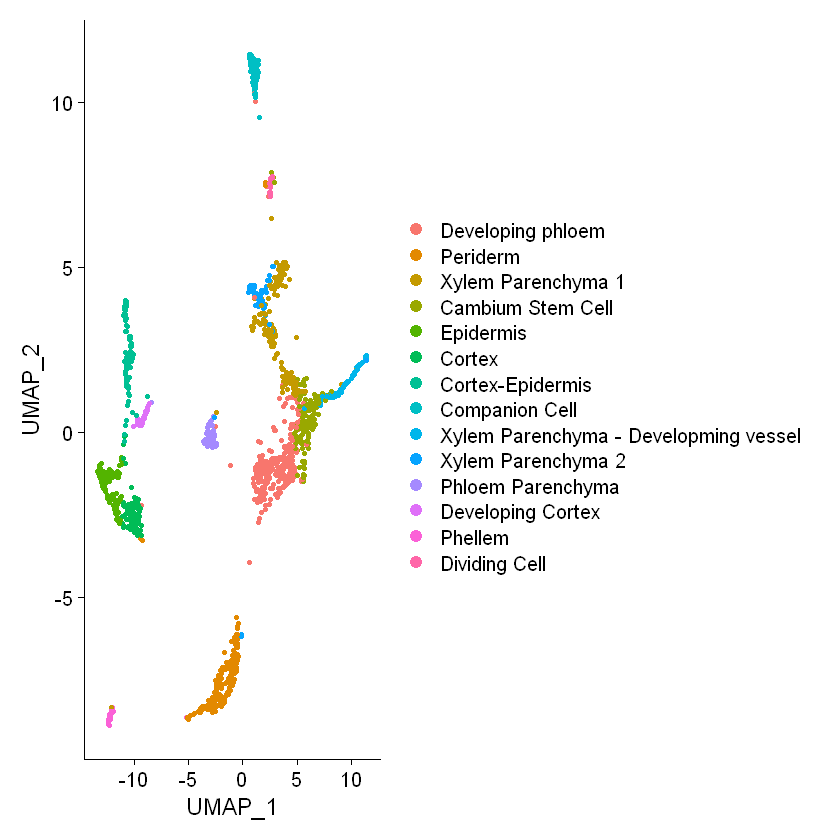

In [6]:
DimPlot(seurat_obj)

There are two main user functions: LoadSensors() and CalcSensors(). They can be investigated via docs or README on the main repo page.

In [7]:
testPanel <- LoadSensors(setName = 'testPanelSet', species = 'AT', hormone = 'cyt', customPanels = FALSE,
                          randomInfo = list('n' = 3, 'sizes' = c(100, 200, 300), majortrend = TRUE),
                          metaPanels = list(
                            'meta1' = list('srcPanels' = c("AT_cyt_cis_ARR1_1", "AT_cyt_cistrans_ARR1_1down"), rule = mean),
                            'meta2' = list('srcPanels' = c("AT_cyt_cis_ARR1_1", "AT_cyt_cistrans_ARR1_1down"), rule = prod))
                          )

LoadSensors is used to create iSensorsPanelSet object for futher calculations. 

In [8]:
cat("Structure of", class(testPanel) , "object:\n")
print(names(testPanel))

cat("\npanelSetName:", testPanel$panelSetName, "\n")
cat("Number of default panels:", length(testPanel$panels), "\n")
cat(head(names(testPanel$panels)), sep=', ',  "...\n")

cat("\nSome default panels added following the arguments:\n")
cat("AT_cyt_cis_ARR1_1 panel length:", length(testPanel$panels[['AT_cyt_cis_ARR1_1']]), "\n")
cat(head(testPanel$panels[['AT_cyt_cis_ARR1_1']]), sep=', ',  "...\n")
cat("AT_cyt_cis_ARR1_2 panel length:", length(testPanel$panels[['AT_cyt_cis_ARR1_2']]), "\n")
cat(head(testPanel$panels[['AT_cyt_cis_ARR1_2']]), sep=', ',  "...\n")

cat("\nStructure of additionel field information:\n")
str(testPanel$additional)

Structure of iSensorsPanelSet object:
[1] "panelSetName" "panels"       "additional"  

panelSetName: testPanelSet 
Number of default panels: 34 
AT_cyt_cis_ARR1_1, AT_cyt_cis_ARR1_2, AT_cyt_cis_ARR10_1, AT_cyt_cis_ARR10_2, AT_cyt_cis_ARR11, AT_cyt_cis_ARR12, ...

Some default panels added following the arguments:
AT_cyt_cis_ARR1_1 panel length: 10285 
AT1G01020, AT1G01060, AT1G01070, AT1G01080, AT1G01090, AT1G01115, ...
AT_cyt_cis_ARR1_2 panel length: 9472 
AT1G01060, AT1G01080, AT1G01090, AT1G01170, AT1G01190, AT1G01230, ...

Structure of additionel field information:
List of 2
 $ random:List of 3
  ..$ n         : num 3
  ..$ sizes     : num [1:3] 100 200 300
  ..$ majortrend: logi TRUE
 $ meta  :List of 2
  ..$ meta1:List of 2
  .. ..$ srcPanels: chr [1:2] "AT_cyt_cis_ARR1_1" "AT_cyt_cistrans_ARR1_1down"
  .. ..$ rule     :function (x, ...)  
  ..$ meta2:List of 2
  .. ..$ srcPanels: chr [1:2] "AT_cyt_cis_ARR1_1" "AT_cyt_cistrans_ARR1_1down"
  .. ..$ rule     :function (..., na.rm 

CalcSensors is used to calculate sensor signals for seurat object or expression matrix.

In [9]:
seurat_obj <- CalcSensors(seurat_obj,
                      seurLayer = 'data',
                      panelSet = testPanel,
                      signals = c("mean_normed", "median"))

  |==================================================| 100%


mean_normed signal was calculated

Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"


  |==================================================| 100%


median signal was calculated

Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"


When using a seurat object the one can access the new matrix for sensor signals.

In [10]:
cat("\nAssays:\n")
cat(Assays(seurat_obj), sep=', ', fill=TRUE)

print(seurat_obj[['iSensors_mean_normed']])

cat('\ngenerated random and meta panels:\n')
cat(tail(rownames(GetAssayData(seurat_obj, assay = "iSensors_mean_normed", layer = "data"))))


Assays:
RNA, iSensors_mean_normed, iSensors_median
Assay data with 40 features for 1368 cells
First 10 features:
 AT-cyt-cis-ARR1-1, AT-cyt-cis-ARR1-2, AT-cyt-cis-ARR10-1,
AT-cyt-cis-ARR10-2, AT-cyt-cis-ARR11, AT-cyt-cis-ARR12,
AT-cyt-cis-ARR14, AT-cyt-cis-ARR18, AT-cyt-cis-ARR2, AT-cyt-cis-RGATY 

generated random and meta panels:
random1 random2 random3 majortrend meta1 meta2